# GANrec vs gridrec on Real APS Beamtime Data (cfg59)

Direct comparison of `gridrec` and `GANtomo` reconstructions on 4×-downsampled projections from the Oct 2025 APS beamtime. GANrec is run on a single slice; the final cell runs it over the full volume.

For a walkthrough of how GANrec works internally, see [ganrec_phantom_walkthrough.ipynb](ganrec_phantom_walkthrough.ipynb).

## 1. Setup

In [1]:
import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt

from tomoDataClass import tomoData
from helperFunctions import MoviePlotter, convert_to_numpy

from ganrectorch.ganrec import GANtomo
from ganrectorch.propagators import RadonTransform
from ganrectorch.models import Generator

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch GPU detected.
Torch device: cuda
GPU: Tesla P100-PCIE-16GB


In [2]:
# ── Config ──────────────────────────────────────────────────────────────
# ALIGNED_TIFF = '/home/ljh79/TomoMono/alignedProjections/APSbeamtime_Oct25/cfg59_ds4x_aligned_20260505-121404.tif'
ALIGNED_TIFF = '/home/ljh79/TomoMono/alignedProjections/APSbeamtime_Oct25/bestNotebookAlignedProjections(4xds).tiff'
RAW_HDF5     = '/home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2.hdf5'

ITER_NUM   = 1000                   # GAN iterations per slice
RECON_ALG  = 'gridrec'              # baseline algorithm for the volume reconstruction
SLICE_IDX  = None                   # None → use centre slice; or set an integer
RNG_SEED   = 0

torch.manual_seed(RNG_SEED); np.random.seed(RNG_SEED)

## 2. Load the pre-aligned projections + angles

Projections come from the 4×-downsampled aligned TIFF saved by the alignment pipeline. Angles are read from the original HDF5 and centred around 0.

In [3]:
def _load_angles_from_hdf5(path):
    """Read angles from the source HDF5 and centre them around 0 (radians)."""
    with h5py.File(path, 'r') as hf:
        ang_deg = hf['angles'][...]
    ang_rad = ang_deg * np.pi / 180.0
    
    drop_idx = [19, 26]
    ang_rad = np.delete(ang_rad, drop_idx, axis=0)
    return ang_rad - np.mean(ang_rad)

print(f'Loading pre-aligned TIFF: {ALIGNED_TIFF}')
projections, _ = convert_to_numpy(ALIGNED_TIFF)
projections = projections.astype(np.float32)
print(f'  projections shape (n_angles, h, w): {projections.shape}')

angles = _load_angles_from_hdf5(RAW_HDF5)
assert len(angles) == projections.shape[0], (
    f'angle count {len(angles)} ≠ projection count {projections.shape[0]}. '
    f'Adjust _load_angles_from_hdf5 to match the TIFF.'
)
print(f'  angles loaded from HDF5: {len(angles)}  '
      f'range [{np.degrees(angles.min()):.2f}, {np.degrees(angles.max()):.2f}] deg')

tomo = tomoData(projections, angles)
tomo.finalProjections = projections.copy()
tomo.workingProjections = projections.copy()

print(f'\nReady — projections {projections.shape}, angles {tomo.ang.shape}')
print(f'Angle span: {np.degrees(tomo.ang.max() - tomo.ang.min()):.2f}° covered  '
      f'→ ~{180 - np.degrees(tomo.ang.max() - tomo.ang.min()):.0f}° missing wedge')

Loading pre-aligned TIFF: /home/ljh79/TomoMono/alignedProjections/APSbeamtime_Oct25/bestNotebookAlignedProjections(4xds).tiff
  projections shape (n_angles, h, w): (556, 146, 452)
  angles loaded from HDF5: 556  range [-65.63, 65.17] deg

Ready — projections (556, 146, 452), angles (556,)
Angle span: 130.80° covered  → ~49° missing wedge


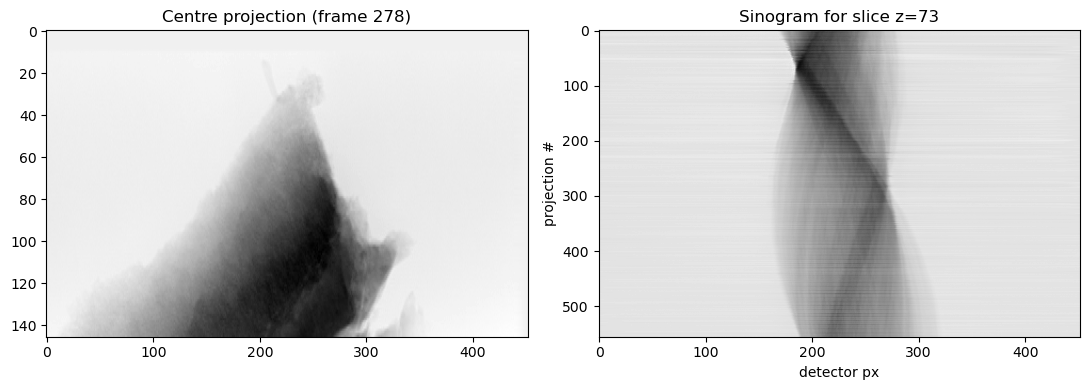

In [4]:
if SLICE_IDX is None:
    SLICE_IDX = projections.shape[1] // 2

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(projections[projections.shape[0] // 2], cmap='gray', aspect='auto')
ax[0].set_title(f'Centre projection (frame {projections.shape[0] // 2})')
ax[1].imshow(projections[:, SLICE_IDX, :], cmap='gray', aspect='auto')
ax[1].set_title(f'Sinogram for slice z={SLICE_IDX}'); ax[1].set_xlabel('detector px'); ax[1].set_ylabel('projection #')
plt.tight_layout(); plt.show()

## 3. Baseline reconstruction — tomopy `gridrec` on the full volume



Using CPU-based reconstruction. Algorithm:  gridrec
Reconstruction completed.
gridrec volume shape: (146, 452, 452)


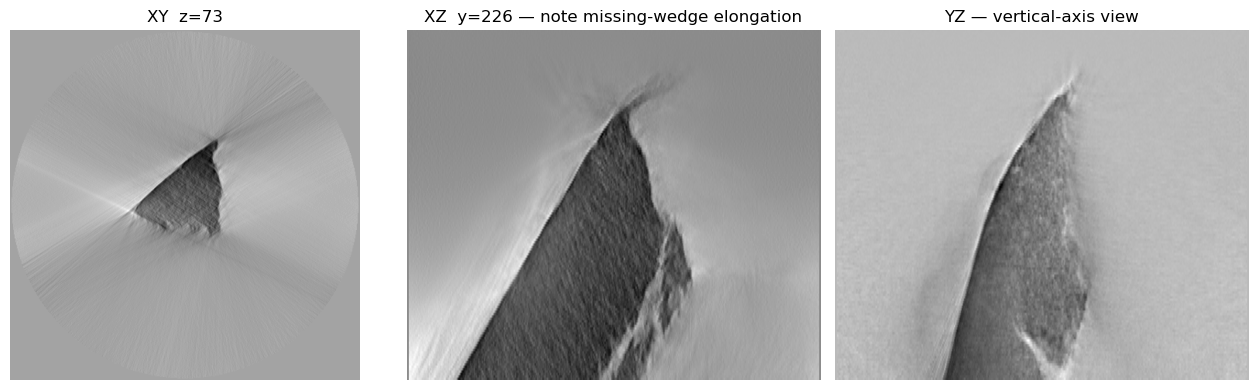

In [5]:
tomo.reconstruct(algorithm=RECON_ALG)
gridrec_vol = tomo.recon
print(f'{RECON_ALG} volume shape: {gridrec_vol.shape}')

cy, cz = gridrec_vol.shape[1] // 2, gridrec_vol.shape[0] // 2
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(gridrec_vol[SLICE_IDX], cmap='gray'); ax[0].set_title(f'XY  z={SLICE_IDX}')
ax[1].imshow(gridrec_vol[:, cy, :], cmap='gray', aspect='auto'); ax[1].set_title(f'XZ  y={cy} — note missing-wedge elongation')
ax[2].imshow(gridrec_vol[:, :, gridrec_vol.shape[2] // 2], cmap='gray', aspect='auto'); ax[2].set_title('YZ — vertical-axis view')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 4. Run `GANtomo` on a slice

In [6]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

prj_slice  = projections[:, SLICE_IDX, :].astype(np.float32)
angles_rad = tomo.ang.astype(np.float32)
ang_t      = torch.from_numpy(angles_rad).to(DEVICE)

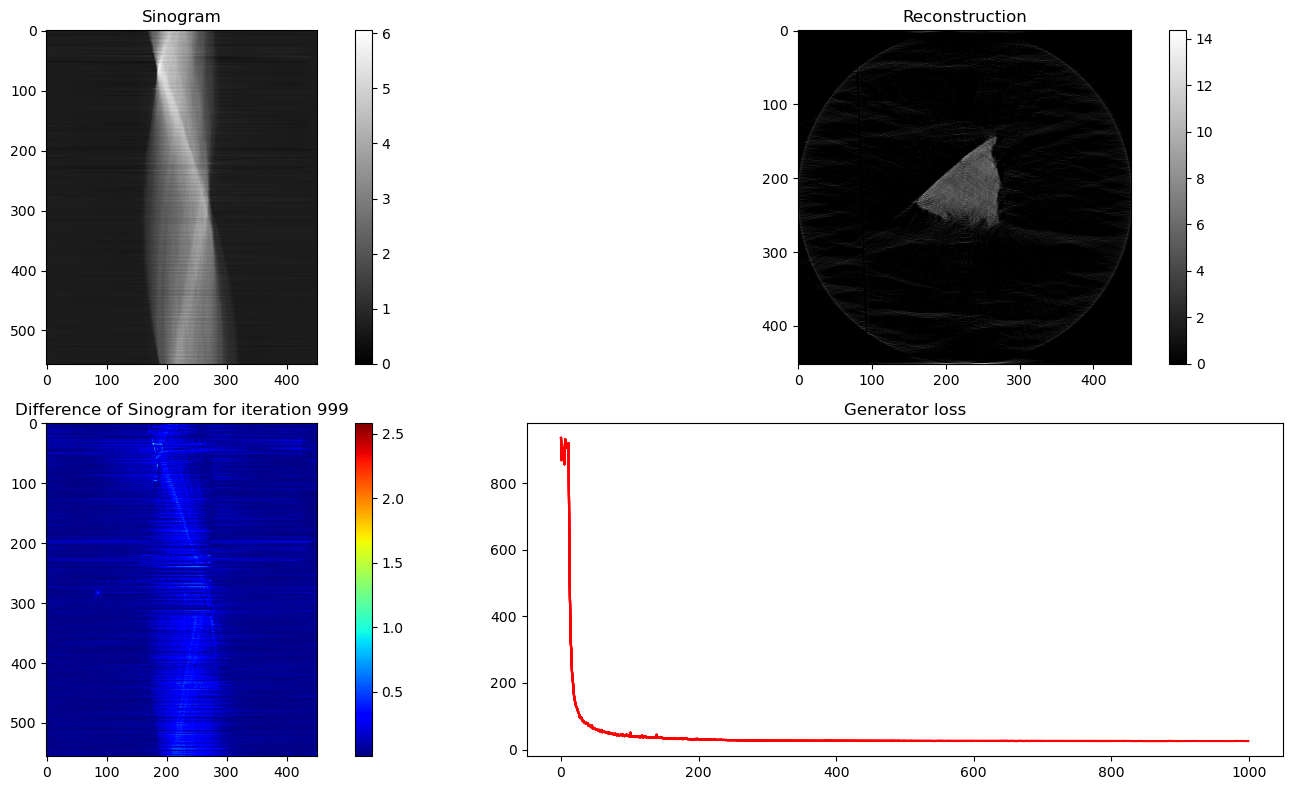

Reconstruction Progress: 100%|██████████| 1000/1000 [08:43<00:00,  1.91it/s, D_loss=1.66, G_loss=25.6]

ganrec slice shape: (452, 452)


In [7]:
torch.manual_seed(RNG_SEED)
# ganrec_slice = GANtomo(-prj_slice, angles_rad, iter_num=ITER_NUM, recon_monitor=True).recon()
ganrec_slice = GANtomo(-prj_slice, angles_rad, iter_num=1000, l1_ratio=300, g_learning_rate= 5e-4, recon_monitor=True).recon()

ganrec_slice = np.asarray(ganrec_slice)
while ganrec_slice.ndim > 2:
    ganrec_slice = ganrec_slice[0]
print(f'ganrec slice shape: {ganrec_slice.shape}')

## 5. Compare — gridrec vs GANrec

Side-by-side visual comparison with GANrec scaled to gridrec's value range, plus a reprojection-consistency (L1) score for each method.

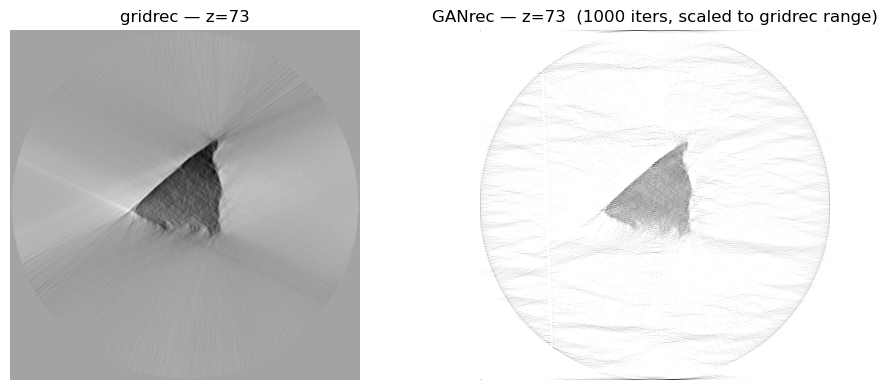

Method         L1(reprojection − measured) ↓
----------------------------------------------
gridrec                               2.2822
ganrec                                2.3457


In [8]:
def torch_nor_tomo(x):
    x = (x - x.mean()) / x.std()
    return x - x.min()

gridrec_s    = gridrec_vol[SLICE_IDX]
ganrec_flipped = -ganrec_slice  # GANtomo was called with negated projections

# Rescale GANrec to match gridrec's value range
gr_min, gr_max = float(gridrec_s.min()), float(gridrec_s.max())
gn_min, gn_max = float(ganrec_flipped.min()), float(ganrec_flipped.max())
ganrec_scaled  = (ganrec_flipped - gn_min) / (gn_max - gn_min + 1e-8) * (gr_max - gr_min) + gr_min

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(gridrec_s,    cmap='gray', vmin=gr_min, vmax=gr_max)
ax[0].set_title(f'{RECON_ALG} — z={SLICE_IDX}')
ax[1].imshow(ganrec_scaled, cmap='gray', vmin=gr_min, vmax=gr_max)
ax[1].set_title(f'GANrec — z={SLICE_IDX}  ({ITER_NUM} iters, scaled to gridrec range)')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

# Reprojection-consistency check
def reproject(img_2d, angles_rad_t):
    t = torch.from_numpy(img_2d.astype(np.float32)).view(1, 1, *img_2d.shape).to(DEVICE)
    radon_local = RadonTransform(torch.empty(1, 1, img_2d.shape[0], img_2d.shape[1], device=DEVICE),
                                 angles_rad_t).to(DEVICE)
    with torch.no_grad():
        r = torch_nor_tomo(radon_local(torch_nor_tomo(t), angles_rad_t))
    return r[0, 0].cpu().numpy()

meas_n  = (prj_slice - prj_slice.mean()) / prj_slice.std()
meas_n -= meas_n.min()

rep_gr = reproject(gridrec_s,      ang_t)
rep_gn = reproject(ganrec_flipped, ang_t)

l1_gr = float(np.mean(np.abs(meas_n - rep_gr)))
l1_gn = float(np.mean(np.abs(meas_n - rep_gn)))
print(f"{'Method':<10}  {'L1(reprojection − measured) ↓':>32}")
print(f"{'-' * 46}")
print(f"{RECON_ALG:<10}  {l1_gr:>32.4f}")
print(f"{'ganrec':<10}  {l1_gn:>32.4f}")

## 6. Full 3-D GANrec reconstruction

GANtomo is 2-D, so a full volume means looping over every Y slice. For the 4× downsampled data (~146 slices for cfg59) at `ITER_NUM=1000` on one GPU this typically takes **1–4 hours**.

In [ ]:
# ⚠ SLOW — uncomment to run the full 3-D ganrec reconstruction.

from tqdm.notebook import tqdm as tqdm_nb

n_slices, _, w = projections.shape[1], projections.shape[0], projections.shape[2]
ganrec_vol = np.zeros((projections.shape[1], w, w), dtype=np.float32)
for y in tqdm_nb(range(projections.shape[1]), desc='ganrec slices'):
    sino = projections[:, y, :].astype(np.float32)
    out = GANtomo(sino, angles_rad, iter_num=ITER_NUM, recon_monitor=False).recon()
    out = np.asarray(out)
    while out.ndim > 2:
        out = out[0]
    ganrec_vol[y] = out

print('ganrec volume shape:', ganrec_vol.shape)
MoviePlotter(ganrec_vol)

ganrec slices:   0%|          | 0/146 [00:00<?, ?it/s]